# Termination Probability

> Measure and visualize how often recall stops at each output position.

The termination probability curve summarizes when participants stop recalling. Two modes are available: *simple* mode reports the raw proportion of trials that terminate at each output position, while *conditional* mode divides by how many trials reached that position, giving a stopping hazard rate.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `mode` | `"conditional"` or `"simple"` |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.termination_probability import (
    conditional_termination_probability,
    plot_termination_probability,
    simple_termination_probability,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
mode = "conditional"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

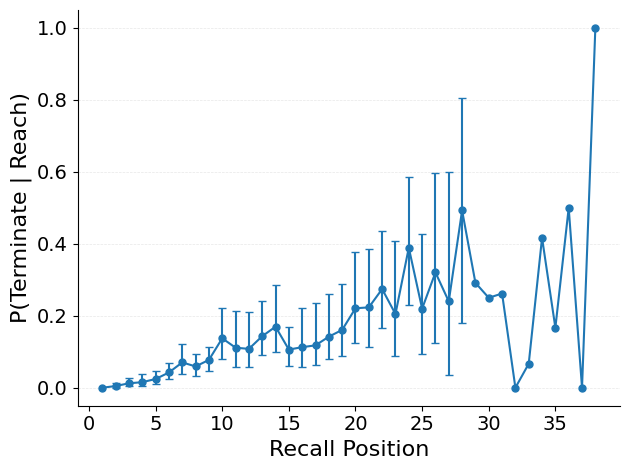

In [5]:
#| code-summary: Plot termination probability
#| label: fig-termination
#| fig-cap: "Termination probability by recall output position."
plot_termination_probability(data, trial_mask, mode=mode)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_termination_probability)

---

### plot_termination_probability

>      plot_termination_probability (datasets:Union[Sequence[jaxcmr.typing.Recal
>                                    lDataset],jaxcmr.typing.RecallDataset], tri
>                                    al_masks:Union[Sequence[jaxtyping.Bool[Arra
>                                    y,'trial_count']],jaxtyping.Bool[Array,'tri
>                                    al_count']], mode:str='conditional',
>                                    color_cycle:Optional[list[str]]=None,
>                                    labels:Optional[Sequence[str]]=None,
>                                    contrast_name:Optional[str]=None, axis:Opti
>                                    onal[matplotlib.axes._axes.Axes]=None,
>                                    confidence_level:float=0.95)

*Plot termination probability curves.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| mode | str | conditional | ``"conditional"`` or ``"simple"``. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with termination curves.** |

In [7]:
#| echo: false
show_doc(conditional_termination_probability)

---

### conditional_termination_probability

>      conditional_termination_probability (dataset:jaxcmr.typing.RecallDataset)

*Conditional termination probability by recall position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls``. |
| **Returns** | **Float[Array, 'recall_positions']** | **P(stop \| reached) at each output position.** |

In [8]:
# One trial fills all slots, the other stops after one recall
dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 4, dtype=jnp.int32),
    "recalls": jnp.array([[1, 2, 3, 4], [7, 0, 0, 0]], dtype=jnp.int32),
}

hazard = conditional_termination_probability(dataset)
# P(stop|reached): position 2 = 0.5, position 4 = 1.0
assert jnp.allclose(hazard, jnp.array([0.0, 0.5, 0.0, 1.0]))

In [9]:
#| echo: false
show_doc(simple_termination_probability)

---

### simple_termination_probability

>      simple_termination_probability (dataset:jaxcmr.typing.RecallDataset)

*Termination probability by recall position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls``. |
| **Returns** | **Float[Array, 'recall_positions']** | **Probability of stopping at each output position.** |

In [10]:
# Both trials stop after the first recall
dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 4, dtype=jnp.int32),
    "recalls": jnp.array([[5, 0, 0, 0], [8, 0, 0, 0]], dtype=jnp.int32),
}

curve = simple_termination_probability(dataset)
assert jnp.allclose(curve, jnp.array([0.0, 1.0, 0.0, 0.0]))